/tmp/ipython-input-1702402965.py:67: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1702402965.py:69: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUT_DIR}/plots/{save_name}.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


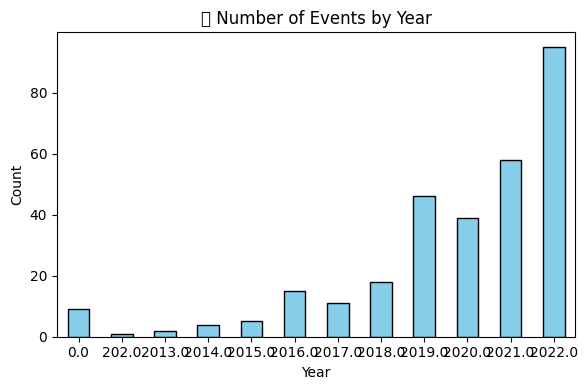

/tmp/ipython-input-1702402965.py:67: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1702402965.py:69: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUT_DIR}/plots/{save_name}.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


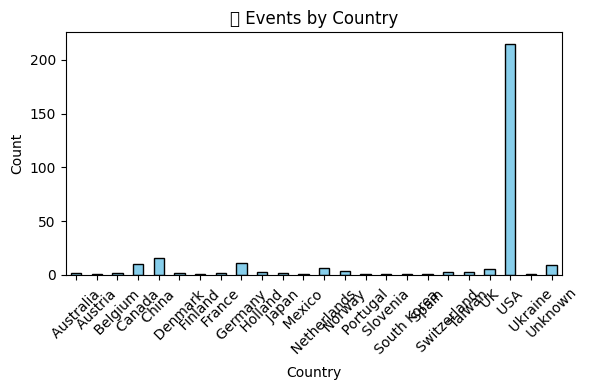

/tmp/ipython-input-1702402965.py:67: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1702402965.py:69: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUT_DIR}/plots/{save_name}.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


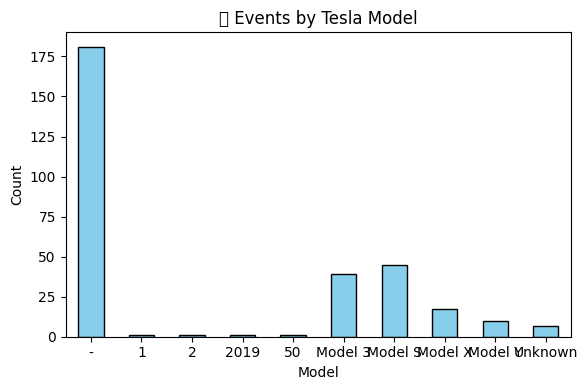

/tmp/ipython-input-1702402965.py:76: UserWarning: Glyph 129485 (\N{STANDING PERSON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1702402965.py:78: UserWarning: Glyph 129485 (\N{STANDING PERSON}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUT_DIR}/plots/{save_name}.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129485 (\N{STANDING PERSON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


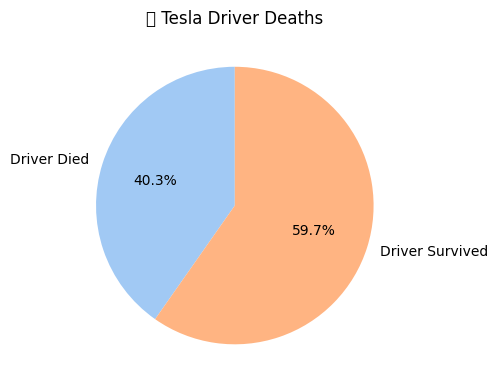

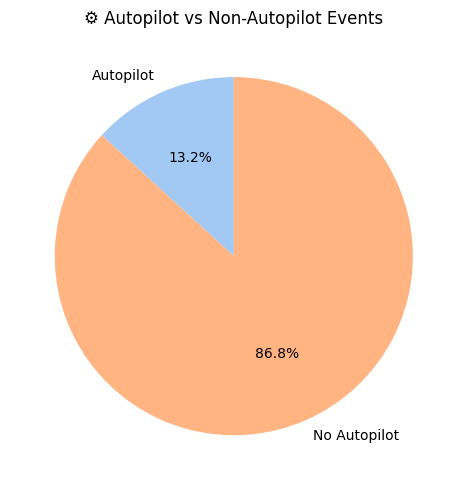

/tmp/ipython-input-1702402965.py:114: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1702402965.py:115: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUT_DIR}/plots/correlation_heatmap.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


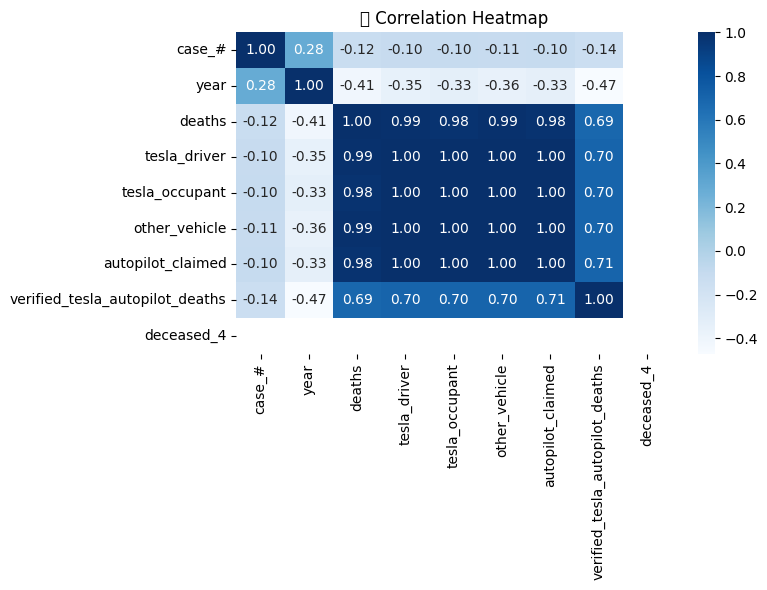


📊 Model-wise Summary:
     model  total_cases  total_deaths  autopilot_cases  verified_autopilot
0        -          181           219               13                   5
1        1            1             1                0                   0
2        2            1             1                0                   0
3     2019            1          2013             2020                2021
4       50            1             3               47                  75
5  Model 3           39            47               10                   7
6  Model S           45            53                9                   5
7  Model X           17            19                4                   1
8  Model Y           10            13                2                   1
9  Unknown            7           706               76                2178

✅ Cleaned data → /content/tesla_safety_analysis/data/tesla_deaths_cleaned.csv
✅ Report → /content/tesla_safety_analysis/reports/summary.txt
✅ Charts → 

In [1]:
# 🚗 Tesla Autopilot Safety Analysis (Final Visual Version)
# Works directly with: /content/Tesla - Deaths.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as stats
from textwrap import dedent

# ==============================
# 1️⃣ Setup paths
# ==============================
DATA_PATH = '/content/Tesla - Deaths.csv'
OUTPUT_DIR = '/content/tesla_safety_analysis'
os.makedirs(f'{OUTPUT_DIR}/data', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/reports', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/plots', exist_ok=True)

# ==============================
# 2️⃣ Load & basic clean
# ==============================
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna('Unknown').astype(str)
for col in df.select_dtypes(include='number'):
    df[col] = df[col].fillna(0)

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

df = df.drop_duplicates().dropna(how='all').reset_index(drop=True)

# Safe numeric conversion
def to_numeric_safe(series):
    return pd.to_numeric(series.replace({'Yes':1,'No':0,'Y':1,'N':0,'TRUE':1,'FALSE':0}), errors='coerce').fillna(0).astype(int)

for col in ['deaths','tesla_driver','tesla_occupant','other_vehicle','cyclists_peds','tsla_cycl_peds',
            'autopilot_claimed','verified_tesla_autopilot_deaths']:
    if col in df.columns:
        df[col] = to_numeric_safe(df[col])

# Standardize model names
def clean_model(m):
    m = str(m).lower().strip()
    mapping = {'3':'Model 3','s':'Model S','x':'Model X','y':'Model Y'}
    for k,v in mapping.items():
        if k in m:
            return v
    return m.title() if m else 'Unknown'

if 'model' in df.columns:
    df['model'] = df['model'].apply(clean_model)

# ==============================
# 3️⃣ EDA Helper Functions
# ==============================
def plot_bar(series, title, xlabel, ylabel, rotation=0, save_name=None):
    plt.figure(figsize=(6,4))
    series.value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    if save_name:
        plt.savefig(f'{OUTPUT_DIR}/plots/{save_name}.png', dpi=150)
    plt.show()

def plot_pie(series, title, labels, save_name=None):
    plt.figure(figsize=(5,5))
    plt.pie(series, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    plt.title(title)
    plt.tight_layout()
    if save_name:
        plt.savefig(f'{OUTPUT_DIR}/plots/{save_name}.png', dpi=150)
    plt.show()

# ==============================
# 4️⃣ Core Visuals
# ==============================
if 'year' in df.columns:
    plot_bar(df['year'], '📆 Number of Events by Year', 'Year', 'Count', save_name='events_by_year')

if 'country' in df.columns:
    plot_bar(df['country'], '🌍 Events by Country', 'Country', 'Count', rotation=45, save_name='events_by_country')

if 'model' in df.columns:
    plot_bar(df['model'], '🚗 Events by Tesla Model', 'Model', 'Count', save_name='events_by_model')

# Pie charts for proportions
if 'tesla_driver' in df.columns:
    plot_pie([(df['tesla_driver']>0).sum(), (df['tesla_driver']==0).sum()],
             '🧍 Tesla Driver Deaths', ['Driver Died','Driver Survived'], save_name='driver_deaths')

if 'cyclists_peds' in df.columns:
    plot_pie([(df['cyclists_peds']>0).sum(), (df['cyclists_peds']==0).sum()],
             '🚴 Cyclist/Pedestrian Involvement', ['Involved','Not Involved'], save_name='cyclist_ped')

if 'autopilot_claimed' in df.columns:
    plot_pie([(df['autopilot_claimed']>0).sum(), (df['autopilot_claimed']==0).sum()],
             '⚙️ Autopilot vs Non-Autopilot Events', ['Autopilot','No Autopilot'], save_name='autopilot_distribution')

# ==============================
# 5️⃣ Heatmap Correlation
# ==============================
num_cols = df.select_dtypes(include=np.number).columns
if len(num_cols) > 2:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues', fmt=".2f")
    plt.title("🔥 Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/plots/correlation_heatmap.png', dpi=150)
    plt.show()

# ==============================
# 6️⃣ Analytical Calculations
# ==============================
results = {}
if 'deaths' in df.columns: results['Total Deaths'] = int(df['deaths'].sum())
if 'tesla_driver' in df.columns: results['Tesla Driver Deaths'] = int((df['tesla_driver']>0).sum())
if 'tesla_occupant' in df.columns:
    multi_occ = (df['tesla_occupant']>1).sum()
    results['Multi-Occupant Deaths'] = f"{multi_occ} cases ({multi_occ/len(df)*100:.1f}%)"
if 'cyclists_peds' in df.columns: results['Cyclist/Pedestrian Events'] = int((df['cyclists_peds']>0).sum())
if {'tesla_driver','cyclists_peds'}.issubset(df.columns):
    combo = ((df['tesla_driver']>0)&(df['cyclists_peds']>0)).sum()
    results['Driver+Cyclist/Pedestrian Deaths'] = int(combo)
if 'other_vehicle' in df.columns: results['Tesla Collisions with Other Vehicles'] = int((df['other_vehicle']>0).sum())

# ==============================
# 7️⃣ Model & Autopilot Distribution
# ==============================
model_summary = None
if {'model','autopilot_claimed'}.issubset(df.columns):
    model_summary = df.groupby('model').agg(
        total_cases=('model','size'),
        total_deaths=('deaths','sum'),
        autopilot_cases=('autopilot_claimed','sum'),
        verified_autopilot=('verified_tesla_autopilot_deaths','sum')
    ).reset_index()
    print("\n📊 Model-wise Summary:")
    print(model_summary)

# ==============================
# 8️⃣ Statistical Test
# ==============================
if {'autopilot_claimed','deaths'}.issubset(df.columns):
    ap = df[df['autopilot_claimed']>0]['deaths']
    nap = df[df['autopilot_claimed']==0]['deaths']
    if len(ap)>1 and len(nap)>1:
        _, pval = stats.ttest_ind(ap, nap, equal_var=False)
        results['T-Test P-Value (Autopilot vs Non)'] = round(pval,4)

# ==============================
# 9️⃣ Save Clean Data & Report
# ==============================
clean_path = f'{OUTPUT_DIR}/data/tesla_deaths_cleaned.csv'
report_path = f'{OUTPUT_DIR}/reports/summary.txt'
df.to_csv(clean_path, index=False)

with open(report_path,'w') as f:
    f.write("TESLA AUTOPILOT SAFETY ANALYSIS REPORT\n")
    f.write("="*50 + "\n\n")
    for k,v in results.items():
        f.write(f"{k}: {v}\n")

print("\n✅ Cleaned data →", clean_path)
print("✅ Report →", report_path)
print("✅ Charts →", f"{OUTPUT_DIR}/plots/")
print("\n📋 Key Findings:")
for k,v in results.items():
    print(f"{k}: {v}")
print("\n🎯 Analysis + Visuals Complete!")
